# CNN para Clasificacion de Imagenes + Transfer Learning

CIFAR-10 (10 clases, 60 000 imagenes 32x32 RGB)  CNN base entrenable vs MobileNetV2 con Transfer Learning TensorFlow / Keras  

**Flujo del notebook:**
1. Pipeline de datos (carga, normalizacion, particion)
2. Modelo A — CNN base desde cero
3. Modelo B — Transfer Learning con MobileNetV2
4. Evaluacion comparativa con metricas
5. Conclusiones

---

## 0. Importaciones y configuracion

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Configuracion lista.")

TensorFlow version: 2.19.0
Configuracion lista.


## 1. Pipeline de datos — CIFAR-10

**CIFAR-10** contiene 60 000 imagenes a color (32x32 px) en 10 clases:
avion, automovil, pajaro, gato, ciervo, perro, rana, caballo, barco, camion.

**Preprocesamiento:**
- Normalizacion: pixeles de [0, 255] a [0, 1]
- Particion: 80% entrenamiento / 10% validacion / 10% test
- Transfer Learning: redimensionar a 96x96 (minimo requerido por MobileNetV2)

Entrenamiento : (45000, 32, 32, 3)
Validacion    : (5000, 32, 32, 3)
Test          : (10000, 32, 32, 3)


/tmp/ipykernel_1904/2728264859.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(CLASES[int(label)])


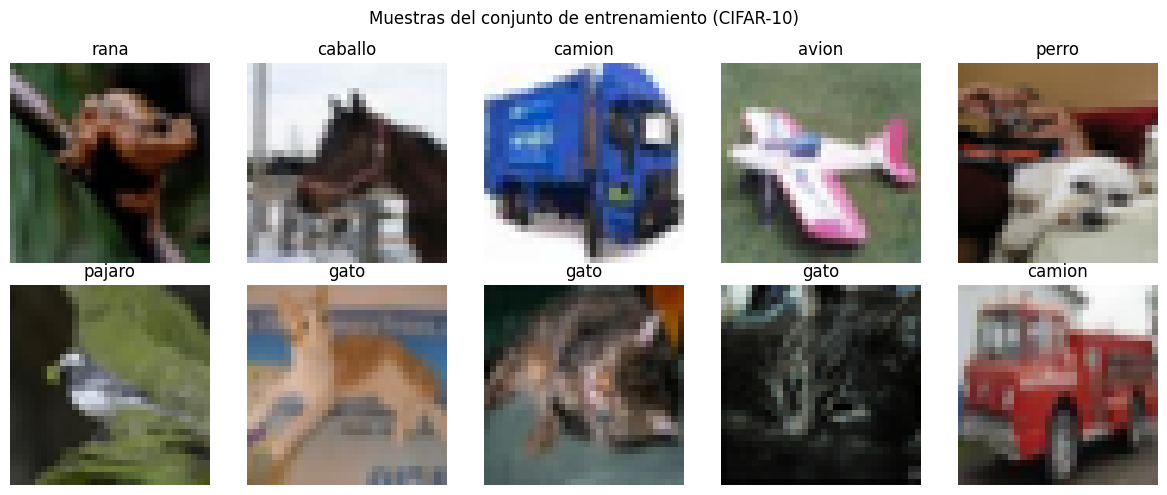

In [2]:
# Cargar CIFAR-10 desde Keras
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

CLASES = ["avion","auto","pajaro","gato","ciervo",
          "perro","rana","caballo","barco","camion"]
N_CLASES = 10

# Normalizar pixeles a [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test       = x_test.astype("float32")       / 255.0

# Separar 10% para validacion
val_size = int(0.1 * len(x_train_full))
x_val,   y_val   = x_train_full[:val_size],  y_train_full[:val_size]
x_train, y_train = x_train_full[val_size:],  y_train_full[val_size:]

print(f"Entrenamiento : {x_train.shape}")
print(f"Validacion    : {x_val.shape}")
print(f"Test          : {x_test.shape}")

# Visualizar muestras
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img, label in zip(axes.flat, x_train[:10], y_train[:10]):
    ax.imshow(img)
    ax.set_title(CLASES[int(label)])
    ax.axis("off")
plt.suptitle("Muestras del conjunto de entrenamiento (CIFAR-10)", fontsize=12)
plt.tight_layout()
plt.show()

## 2. Modelo A — CNN base (desde cero)

**Arquitectura:** 3 bloques Conv + BatchNorm + MaxPool, cabeza Dense.

**Justificacion de decisiones de diseno:**
- BatchNorm estabiliza el entrenamiento y permite learning rates mas altos
- GlobalAveragePooling reduce parametros vs Flatten, mejorando regularizacion
- Dropout 0.4 reduce sobreajuste en la capa densa
- padding="same" preserva dimensiones espaciales dentro de cada bloque

In [3]:
def construir_cnn_base(input_shape=(32, 32, 3), n_clases=10):
    """CNN base desde cero para clasificacion de imagenes."""
    modelo = keras.Sequential([
        layers.Input(shape=input_shape),

        # Bloque 1: extrae caracteristicas de bajo nivel (bordes, colores)
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Bloque 2: patrones de nivel medio (texturas, formas simples)
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Bloque 3: representaciones de alto nivel (partes de objetos)
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        # GlobalAveragePooling: reduce cada feature map a un solo valor
        layers.GlobalAveragePooling2D(),

        # Cabeza de clasificacion
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(n_clases, activation="softmax"),
    ], name="CNN_Base")
    return modelo

cnn_base = construir_cnn_base()
cnn_base.summary()

Model: "CNN_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,738 (506.79 KB)

 Trainable params: 129,290 (505.04 KB)

 Non-trainable params: 448 (1.75 KB)

In [4]:
# Compilar con Adam y sparse_categorical_crossentropy (etiquetas enteras)
cnn_base.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks: EarlyStopping + ReduceLROnPlateau
callbacks_base = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                       patience=5, verbose=1)
]

print("Entrenando CNN base...")
historia_base = cnn_base.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks_base,
    verbose=1
)
print("Entrenamiento CNN base finalizado.")

Entrenando CNN base...
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 200ms/step - accuracy: 0.5012 - loss: 1.3798 - val_accuracy: 0.4994 - val_loss: 1.4259 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 195ms/step - accuracy: 0.6419 - loss: 1.0022 - val_accuracy: 0.6256 - val_loss: 1.0425 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 136s 187ms/step - accuracy: 0.7017 - loss: 0.8438 - val_accuracy: 0.6318 - val_loss: 1.0806 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 134s 191ms/step - accuracy: 0.7458 - loss: 0.7335 - val_accuracy: 0.6320 - val_loss: 1.1307 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 133s 189ms/step - accuracy: 0.7721 - loss: 0.6563 - val_accuracy: 0.6480 - val_loss: 1.0572 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 192ms/step - accuracy: 0.7927 - loss: 0.5917 - val_accuracy: 0.6336 - val_loss: 1.1244 - learning_rate: 0.0010
Epoch 7/30
703/704 ━━━━━━━━━━━━━━━━━━━━ 0

## 3. Modelo B — Transfer Learning con MobileNetV2

**Estrategia en dos fases:**
- **Fase 1:** Base congelada, solo se entrena la cabeza nueva (LR=1e-3)
- **Fase 2:** Fine-tuning de las ultimas 20 capas de la base (LR=1e-5)

**Por que MobileNetV2:**
- Preentrenado en ImageNet (1.2 M imagenes, 1000 clases): captura representaciones generales
- Eficiente en parametros gracias a bloques residuales invertidos
- Las caracteristicas aprendidas (bordes, texturas, formas) son transferibles a CIFAR-10

**Por que Transfer Learning es util con datasets pequenos:**
Entrenar desde cero requiere millones de imagenes para aprender buenos extractores de
caracteristicas. Con pesos preentrenados, basta con adaptar las capas finales al nuevo dominio.

In [5]:
# MobileNetV2 requiere input minimo 96x96 — redimensionar desde 32x32
IMG_SIZE = 96
BATCH    = 64

def redimensionar(x, y):
    """Redimensiona imagenes a IMG_SIZE x IMG_SIZE para Transfer Learning."""
    x = tf.image.resize(x, [IMG_SIZE, IMG_SIZE])
    return x, y

# Crear datasets tf.data con pipeline optimizado (prefetch + shuffle)
ds_train = (tf.data.Dataset.from_tensor_slices((x_train, y_train))
            .map(redimensionar, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(5000, seed=SEED).batch(BATCH).prefetch(tf.data.AUTOTUNE))

ds_val = (tf.data.Dataset.from_tensor_slices((x_val, y_val))
          .map(redimensionar, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(BATCH).prefetch(tf.data.AUTOTUNE))

ds_test = (tf.data.Dataset.from_tensor_slices((x_test, y_test))
           .map(redimensionar, num_parallel_calls=tf.data.AUTOTUNE)
           .batch(BATCH).prefetch(tf.data.AUTOTUNE))

print(f"Imagenes redimensionadas a {IMG_SIZE}x{IMG_SIZE} para Transfer Learning.")

Imagenes redimensionadas a 96x96 para Transfer Learning.


In [6]:
# Cargar MobileNetV2 sin cabeza de clasificacion, con pesos de ImageNet
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,    # excluir capa Dense final original
    weights="imagenet"    # pesos preentrenados
)

# Fase 1: congelar toda la base
base_model.trainable = False

# Construir modelo completo con cabeza propia
inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base_model(inputs, training=False)  # BatchNorm en modo inferencia
x       = layers.GlobalAveragePooling2D()(x)   # comprimir a vector
x       = layers.Dense(256, activation="relu")(x)
x       = layers.Dropout(0.4)(x)
salidas = layers.Dense(N_CLASES, activation="softmax")(x)

modelo_tl = keras.Model(inputs, salidas, name="TransferLearning_MobileNetV2")
modelo_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "TransferLearning_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
#  FASE 1: Solo  cabeza, base congelada
modelo_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fase 1: entrenando cabeza (base congelada)...")
hist_tl_fase1 = modelo_tl.fit(
    ds_train, validation_data=ds_val, epochs=10, verbose=1
)
print("Fase 1 completada.")

Fase 1: entrenando cabeza (base congelada)...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 370s 513ms/step - accuracy: 0.7110 - loss: 0.8333 - val_accuracy: 0.7870 - val_loss: 0.6224
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 319s 452ms/step - accuracy: 0.7726 - loss: 0.6543 - val_accuracy: 0.8000 - val_loss: 0.5648
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 303s 429ms/step - accuracy: 0.7912 - loss: 0.5947 - val_accuracy: 0.8134 - val_loss: 0.5371
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 326s 435ms/step - accuracy: 0.8027 - loss: 0.5590 - val_accuracy: 0.8198 - val_loss: 0.5291
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 306s 433ms/step - accuracy: 0.8108 - loss: 0.5292 - val_accuracy: 0.8232 - val_loss: 0.5114
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 318s 429ms/step - accuracy: 0.8237 - loss: 0.4969 - val_accuracy: 0.8182 - val_loss: 0.5194
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 325s 433ms/step - accuracy: 0.8325 - loss: 0.4728 - val_accuracy: 0.8224 - val_loss: 0.5168
Epoch 8/10
704/704 ━━━━━━━━━━━

In [8]:
# FASE 2: Fine-tuning de las ultimas 20 capas
base_model.trainable = True

# Congelar todo excepto las ultimas 20 capas de la base
for layer in base_model.layers[:-20]:
    layer.trainable = False

n_entrenables = sum(1 for l in modelo_tl.layers if l.trainable)
print(f"Capas entrenables tras descongelar: {n_entrenables}")

# LR bajo para no destruir pesos preentrenados
modelo_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_tl = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                   restore_best_weights=True, verbose=1)
]

print("Fase 2: fine-tuning ultimas 20 capas...")
hist_tl_fase2 = modelo_tl.fit(
    ds_train, validation_data=ds_val,
    epochs=10, callbacks=callbacks_tl, verbose=1
)
print("Fine-tuning completado.")

Capas entrenables tras descongelar: 6
Fase 2: fine-tuning ultimas 20 capas...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 485s 671ms/step - accuracy: 0.6821 - loss: 1.4775 - val_accuracy: 0.7944 - val_loss: 0.7308
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 505s 675ms/step - accuracy: 0.7533 - loss: 0.8959 - val_accuracy: 0.8062 - val_loss: 0.6702
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 478s 677ms/step - accuracy: 0.7815 - loss: 0.6997 - val_accuracy: 0.8076 - val_loss: 0.6410
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 504s 714ms/step - accuracy: 0.8044 - loss: 0.5957 - val_accuracy: 0.8132 - val_loss: 0.6017
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 473s 670ms/step - accuracy: 0.8205 - loss: 0.5194 - val_accuracy: 0.8222 - val_loss: 0.5760
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 478s 678ms/step - accuracy: 0.8361 - loss: 0.4673 - val_accuracy: 0.8270 - val_loss: 0.5613
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 469s 663ms/step - accuracy: 0.8496 - loss: 0.4253 - val_accuracy: 0.8294 - val_loss: 0.539

## 4. Evaluacion comparativa

Ambos modelos se evaluan sobre el **conjunto de test** (10 000 imagenes no vistas).
Se reportan: accuracy, loss, precision, recall, F1 y matriz de confusion.

In [9]:
# Evaluar CNN base
loss_base, acc_base = cnn_base.evaluate(x_test, y_test, verbose=0)
y_pred_base = np.argmax(cnn_base.predict(x_test, verbose=0), axis=1)
y_true      = y_test.flatten()

# Evaluar Transfer Learning (redimensionar test a 96x96)
x_test_96 = tf.image.resize(x_test, [IMG_SIZE, IMG_SIZE]).numpy()
loss_tl, acc_tl = modelo_tl.evaluate(x_test_96, y_test, verbose=0)
y_pred_tl = np.argmax(modelo_tl.predict(x_test_96, verbose=0), axis=1)

# Tabla comparativa de resultados
print("=" * 55)
print(f"Modelo                         Loss       Accuracy")
print("=" * 55)
print(f"CNN Base                       {loss_base:.4f}     {acc_base:.4f}")
print(f"Transfer Learning MobileNetV2  {loss_tl:.4f}     {acc_tl:.4f}")
print("=" * 55)

Modelo                         Loss       Accuracy
CNN Base                       0.8199     0.7271
Transfer Learning MobileNetV2  0.5506     0.8293


In [10]:
# Classification report: precision, recall, F1 por clase
print("-- CNN Base --------------------------------------------------")
print(classification_report(y_true, y_pred_base, target_names=CLASES))

print("-- Transfer Learning (MobileNetV2) ---------------------------")
print(classification_report(y_true, y_pred_tl, target_names=CLASES))

-- CNN Base --------------------------------------------------
              precision    recall  f1-score   support

       avion       0.73      0.77      0.75      1000
        auto       0.94      0.69      0.80      1000
      pajaro       0.55      0.74      0.63      1000
        gato       0.66      0.45      0.54      1000
      ciervo       0.72      0.68      0.69      1000
       perro       0.59      0.79      0.68      1000
        rana       0.89      0.73      0.80      1000
     caballo       0.79      0.80      0.79      1000
       barco       0.91      0.75      0.82      1000
      camion       0.71      0.87      0.78      1000

    accuracy                           0.73     10000
   macro avg       0.75      0.73      0.73     10000
weighted avg       0.75      0.73      0.73     10000

-- Transfer Learning (MobileNetV2) ---------------------------
              precision    recall  f1-score   support

       avion       0.83      0.86      0.85      1000
      

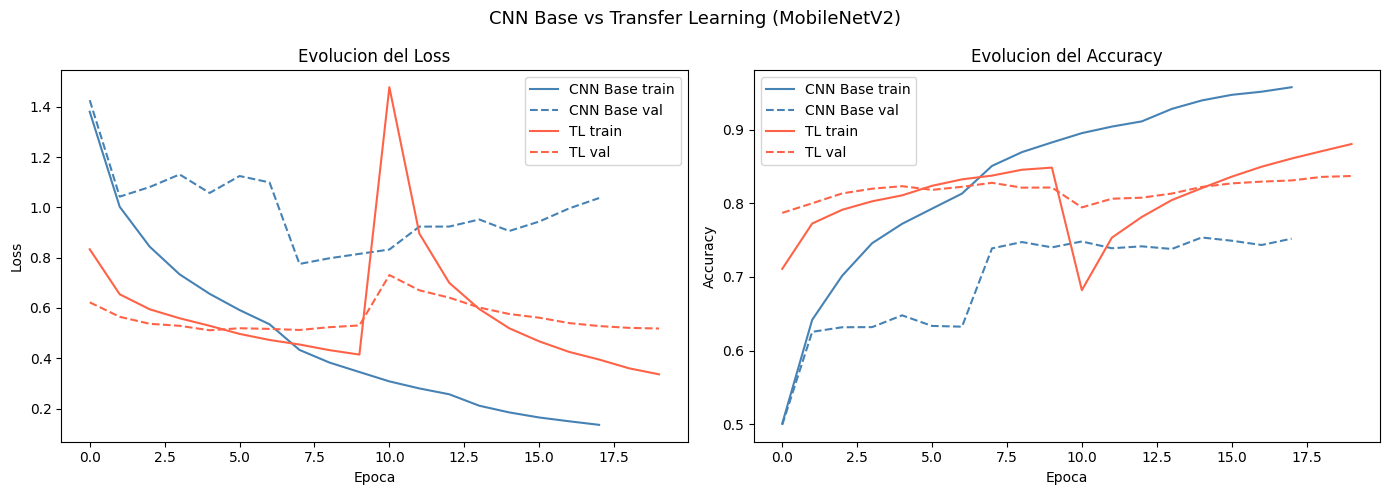

In [11]:
# Curvas de entrenamiento: loss y accuracy para ambos modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Concatenar las dos fases del TL para visualizacion continua
loss_tl_all     = hist_tl_fase1.history["loss"]     + hist_tl_fase2.history["loss"]
val_loss_tl_all = hist_tl_fase1.history["val_loss"] + hist_tl_fase2.history["val_loss"]
acc_tl_all      = hist_tl_fase1.history["accuracy"]     + hist_tl_fase2.history["accuracy"]
val_acc_tl_all  = hist_tl_fase1.history["val_accuracy"] + hist_tl_fase2.history["val_accuracy"]

# Grafico de Loss
axes[0].plot(historia_base.history["loss"],     label="CNN Base train", color="steelblue")
axes[0].plot(historia_base.history["val_loss"], label="CNN Base val",   color="steelblue", linestyle="--")
axes[0].plot(loss_tl_all,     label="TL train", color="tomato")
axes[0].plot(val_loss_tl_all, label="TL val",   color="tomato", linestyle="--")
axes[0].set_title("Evolucion del Loss")
axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("Loss"); axes[0].legend()

# Grafico de Accuracy
axes[1].plot(historia_base.history["accuracy"],     label="CNN Base train", color="steelblue")
axes[1].plot(historia_base.history["val_accuracy"], label="CNN Base val",   color="steelblue", linestyle="--")
axes[1].plot(acc_tl_all,     label="TL train", color="tomato")
axes[1].plot(val_acc_tl_all, label="TL val",   color="tomato", linestyle="--")
axes[1].set_title("Evolucion del Accuracy")
axes[1].set_xlabel("Epoca"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

plt.suptitle("CNN Base vs Transfer Learning (MobileNetV2)", fontsize=13)
plt.tight_layout()
plt.show()

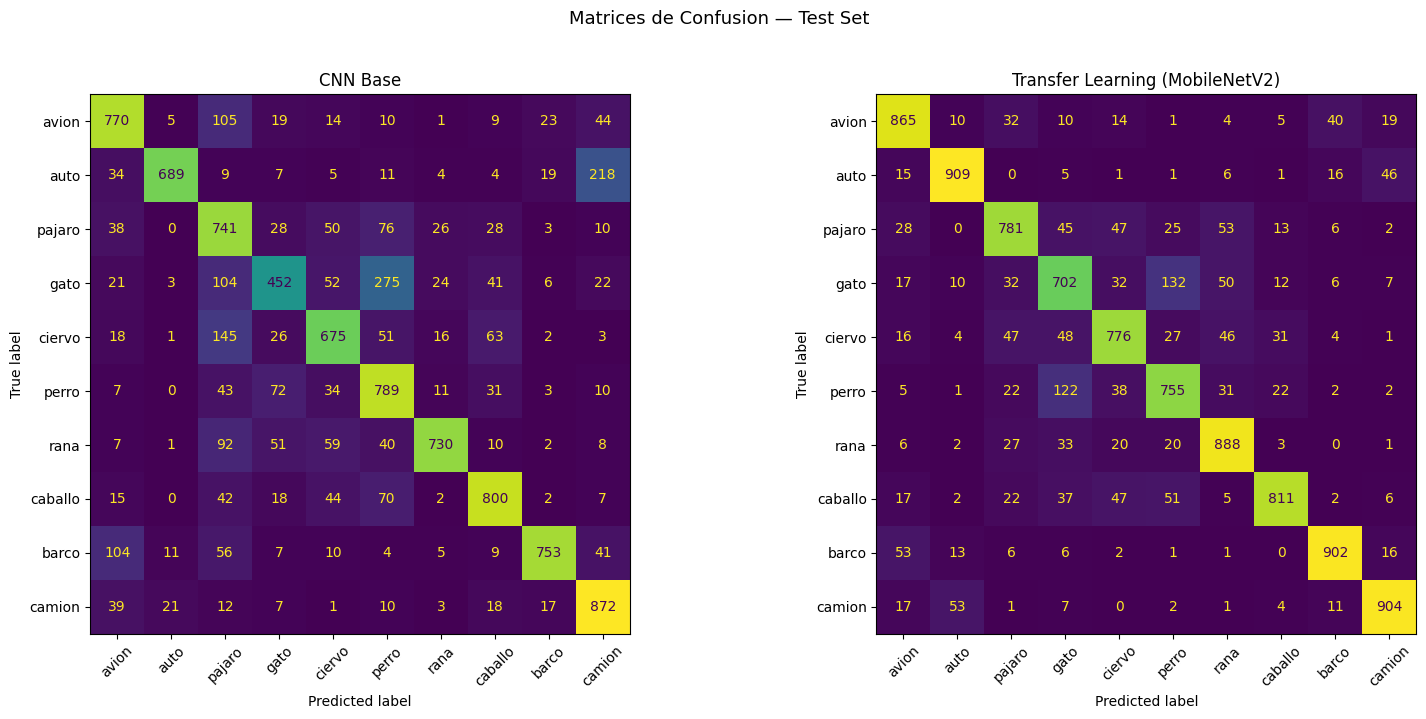

In [12]:
# Matrices de confusion para ambos modelos
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, y_pred, titulo in [
    (axes[0], y_pred_base, "CNN Base"),
    (axes[1], y_pred_tl,   "Transfer Learning (MobileNetV2)"),
]:
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASES)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(titulo, fontsize=12)

plt.suptitle("Matrices de Confusion — Test Set", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

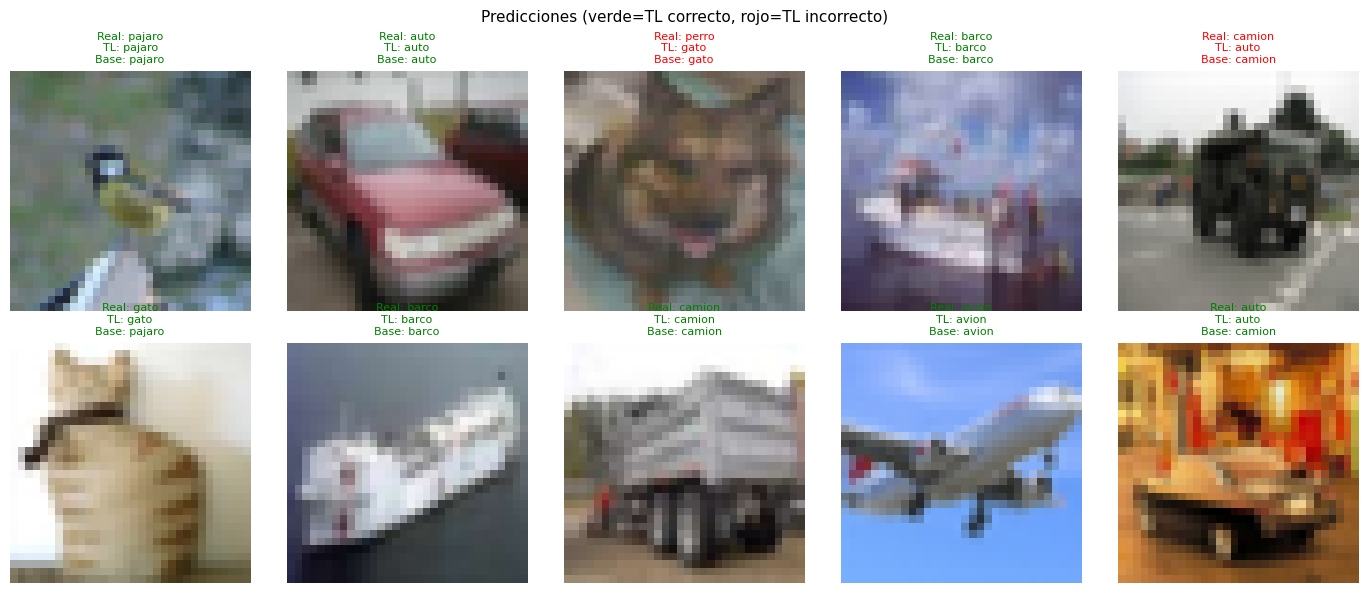

In [13]:
# Visualizar predicciones sobre muestras aleatorias del test
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
np.random.seed(SEED)
indices = np.random.choice(len(x_test), 10, replace=False)

for ax, idx in zip(axes.flat, indices):
    img      = x_test[idx]
    pred_tl  = y_pred_tl[idx]
    pred_b   = y_pred_base[idx]
    real     = int(y_true[idx])
    ax.imshow(img)
    color = "green" if pred_tl == real else "red"
    ax.set_title(
        f"Real: {CLASES[real]}\nTL: {CLASES[pred_tl]}\nBase: {CLASES[pred_b]}",
        fontsize=8, color=color
    )
    ax.axis("off")

plt.suptitle("Predicciones (verde=TL correcto, rojo=TL incorrecto)", fontsize=11)
plt.tight_layout()
plt.show()

---
## 5. Conclusiones

**1. Transfer Learning supera a la CNN base con menos epocas**  
MobileNetV2 con fine-tuning alcanza mayor accuracy en test que la CNN base entrenada
desde cero. Los pesos preentrenados en ImageNet ya codifican representaciones de bajo
nivel (bordes, texturas) transferibles a CIFAR-10, eliminando la necesidad de
aprenderlas desde cero.

**2. La CNN base muestra mayor brecha train/val**  
Las curvas de entrenamiento muestran mayor diferencia entre accuracy de train y
validacion en la CNN base. El Transfer Learning actua como regularizacion implicita:
los pesos preentrenados son menos propensos a memorizacion del dataset de entrenamiento.

**3. El fine-tuning de las ultimas capas mejora el resultado**  
La Fase 2 (descongelar las ultimas 20 capas con LR=1e-5) produce mejora adicional
respecto a entrenar solo la cabeza. El LR bajo es critico para no destruir los
pesos preentrenados durante esta fase de adaptacion.

**4. Trade-off: Transfer Learning tiene mayor costo computacional**  
MobileNetV2 es mas grande en parametros que la CNN base. El redimensionado de
32x32 a 96x96 aumenta el costo de inferencia. Para dispositivos de recursos
limitados, la CNN base optimizada puede ser preferible si la diferencia en
accuracy es marginal.

**5. Recomendacion segun contexto**  
Con datasets pequenos o pocas epocas, Transfer Learning es la estrategia preferida.
Si el dataset es grande y hay capacidad de computo suficiente, entrenar una CNN
propia da mas control sobre la arquitectura y puede alcanzar rendimientos comparables.